# 04 - Train Linear Regression

Using `pd.read_pickle()` for loading engineered datasets.

## 1. Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 2. Load Dataset

In [4]:
import joblib

X_train = joblib.load('data/ready_for_train/X_train.pkl')
X_test = joblib.load('data/ready_for_train/X_test.pkl')

y_train = joblib.load('data/ready_for_train/y_train.pkl')
y_test = joblib.load('data/ready_for_train/y_test.pkl')

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (78789, 44)
X_test : (19698, 44)
y_train: (78789,)
y_test : (19698,)


## 3. Feature Engineering Summary

In [5]:
X_train.head()

,age,Is_Weekend,gender_Female,gender_Male,category_Books,category_Clothing,category_Cosmetics,category_Food & Beverage,category_Shoes,category_Souvenir,...,Month_7,Month_8,Month_9,DayOfWeek_Friday,DayOfWeek_Monday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday
90788,1.370579,0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
43708,-1.228972,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
39198,-0.429110,0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
32303,1.703855,1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
20351,1.170614,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [6]:
print('Number of features:', X_train.shape[1])
X_train.describe()


Number of features: 44


,age,Is_Weekend,gender_Female,gender_Male,category_Books,category_Clothing,category_Cosmetics,category_Food & Beverage,category_Shoes,category_Souvenir,...,Month_7,Month_8,Month_9,DayOfWeek_Friday,DayOfWeek_Monday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday
count,7.878900e+04,78789.000000,78789.000000,78789.000000,78789.000000,78789.000000,78789.00000,78789.000000,78789.000000,78789.000000,...,78789.000000,78789.000000,78789.000000,78789.000000,78789.000000,78789.000000,78789.000000,78789.000000,78789.000000,78789.000000
mean,2.356481e-16,0.284354,0.597825,0.402175,0.049588,0.347231,0.15176,0.148942,0.100458,0.050642,...,0.079998,0.077105,0.075366,0.144424,0.144589,0.141454,0.142901,0.142533,0.143129,0.140971
std,1.000006e+00,0.451109,0.490340,0.490340,0.217094,0.476093,0.35879,0.356034,0.300612,0.219266,...,0.271293,0.266759,0.263982,0.351521,0.351688,0.348491,0.349974,0.349598,0.350207,0.347994
min,-1.695559e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-8.956965e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-2.917924e-02,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8.373380e-01,1.000000,1.000000,1.000000,0.000000,1.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.703855e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 4. Linear Regression - Scikit Learn

In [7]:
start = time.time()

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

train_time_sklearn = time.time() - start

y_pred_sklearn = lr_model.predict(X_test)

mae_sklearn = mean_absolute_error(y_test, y_pred_sklearn)
mse_sklearn = mean_squared_error(y_test, y_pred_sklearn)
rmse_sklearn = np.sqrt(mse_sklearn)
r2_sklearn = r2_score(y_test, y_pred_sklearn)

print(f'MAE  : {mae_sklearn:.4f}')
print(f'MSE  : {mse_sklearn:.4f}')
print(f'RMSE : {rmse_sklearn:.4f}')
print(f'R2   : {r2_sklearn:.4f}')


MAE  : 1751.4492
MSE  : 9335805.2997
RMSE : 3055.4550
R2   : 0.4905


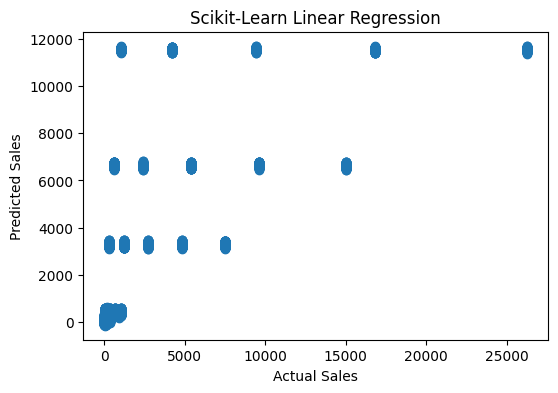

In [8]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_sklearn)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Scikit-Learn Linear Regression')
plt.show()


## 5. Linear Regression From Scratch

In [9]:
class LinearRegressionScratch:

    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.loss_history = []

    def fit(self, X, y):

        X = np.array(X)
        y = np.array(y)

        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.epochs):

            y_pred = np.dot(X, self.weights) + self.bias

            dw = (1/n_samples) * np.dot(X.T, (y_pred - y))
            db = (1/n_samples) * np.sum(y_pred - y)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            self.loss_history.append(
                np.mean((y - y_pred) ** 2)
            )

    def predict(self, X):
        X = np.array(X)
        return np.dot(X, self.weights) + self.bias


In [10]:
start = time.time()

scratch_model = LinearRegressionScratch(
    learning_rate=0.01,
    epochs=1000
)

scratch_model.fit(X_train, y_train)

train_time_scratch = time.time() - start

y_pred_scratch = scratch_model.predict(X_test)

mae_scratch = mean_absolute_error(y_test, y_pred_scratch)
mse_scratch = mean_squared_error(y_test, y_pred_scratch)
rmse_scratch = np.sqrt(mse_scratch)
r2_scratch = r2_score(y_test, y_pred_scratch)

print(f'MAE  : {mae_scratch:.4f}')
print(f'MSE  : {mse_scratch:.4f}')
print(f'RMSE : {rmse_scratch:.4f}')
print(f'R2   : {r2_scratch:.4f}')


MAE  : 2062.3487
MSE  : 11625002.1804
RMSE : 3409.5457
R2   : 0.3656


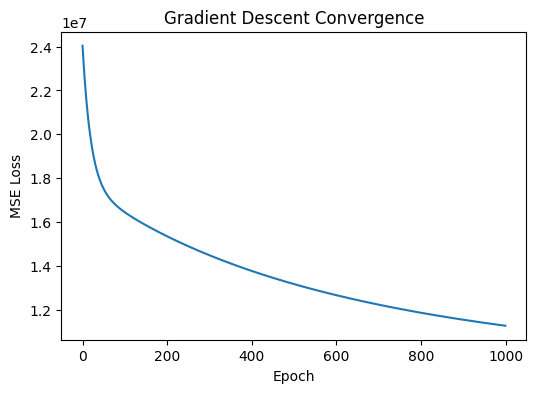

In [11]:
plt.figure(figsize=(6,4))
plt.plot(scratch_model.loss_history)
plt.title('Gradient Descent Convergence')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.show()


## 6. Model Comparison

In [12]:
comparison = pd.DataFrame({
    'Metric':['MAE','MSE','RMSE','R2 Score','Training Time (s)'],
    'Scikit-Learn':[mae_sklearn,mse_sklearn,rmse_sklearn,r2_sklearn,train_time_sklearn],
    'From Scratch':[mae_scratch,mse_scratch,rmse_scratch,r2_scratch,train_time_scratch]
})

comparison


,Metric,Scikit-Learn,From Scratch
0,MAE,1.751449e+03,2.062349e+03
1,MSE,9.335805e+06,1.162500e+07
2,RMSE,3.055455e+03,3.409546e+03
3,R2 Score,4.905430e-01,3.656210e-01
4,Training Time (s),1.763589e-01,4.370130e+00


## 7. Conclusion

Compare both implementations and choose the model with lower RMSE and higher R².